<a href="https://colab.research.google.com/github/MSAI-Student1/AIH-A4/blob/main/MIMIC_Heart_Failure_Readmission_Tutorial_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ==========================================
# 1. Environment Setup & Library Imports
# ==========================================
# We import standard data manipulation and machine learning libraries.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn for modeling and evaluation metrics
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

# Ensure plots are displayed inline in the notebook
%matplotlib inline

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
# ==========================================
# 2. Data Loading (MIMIC-III & MIMIC-IV Compatible)
# ==========================================
import pandas as pd

data_path = './'
print("Reading compressed .csv.gz files directly into memory...")

# We include both MIMIC-III and MIMIC-IV column variations
cols_adm = ['SUBJECT_ID', 'HADM_ID', 'ADMITTIME', 'DISCHTIME', 'ADMISSION_TYPE', 'INSURANCE']
cols_pat = ['SUBJECT_ID', 'GENDER', 'DOB', 'ANCHOR_AGE'] # DOB (MIMIC-III) vs ANCHOR_AGE (MIMIC-IV)
cols_diag = ['SUBJECT_ID', 'HADM_ID', 'ICD9_CODE', 'ICD_CODE'] # ICD9 (MIMIC-III) vs ICD (MIMIC-IV)

df_adm = pd.read_csv(data_path + 'admissions.csv.gz', compression='gzip', usecols=lambda c: c.upper() in cols_adm)
df_adm.columns = df_adm.columns.str.upper()

df_pat = pd.read_csv(data_path + 'patients.csv.gz', compression='gzip', usecols=lambda c: c.upper() in cols_pat)
df_pat.columns = df_pat.columns.str.upper()

df_diag = pd.read_csv(data_path + 'diagnoses_icd.csv.gz', compression='gzip', usecols=lambda c: c.upper() in cols_diag)
df_diag.columns = df_diag.columns.str.upper()

print("\nData loaded successfully!")
print(f"Admissions columns: {list(df_adm.columns)}")
print(f"Patients columns: {list(df_pat.columns)}")
print(f"Diagnoses columns: {list(df_diag.columns)}")

Reading compressed .csv.gz files directly into memory...

Data loaded successfully!
Admissions columns: ['SUBJECT_ID', 'HADM_ID', 'ADMITTIME', 'DISCHTIME', 'ADMISSION_TYPE', 'INSURANCE']
Patients columns: ['SUBJECT_ID', 'GENDER', 'ANCHOR_AGE']
Diagnoses columns: ['SUBJECT_ID', 'HADM_ID', 'ICD_CODE']


In [ ]:
# ==========================================
# 3. Defining the Target: 30-Day Readmission
# ==========================================
import numpy as np

# Dynamically detect the ICD column name based on the MIMIC version
icd_col = 'ICD9_CODE' if 'ICD9_CODE' in df_diag.columns else 'ICD_CODE'

# Filter for Heart Failure Patients
# ICD-9 codes start with '428'. MIMIC-IV also uses ICD-10 codes which start with 'I50'.
hf_mask = df_diag[icd_col].astype(str).str.startswith('428', na=False) | \
          df_diag[icd_col].astype(str).str.startswith('I50', na=False)

hf_diagnoses = df_diag[hf_mask]
hf_hadm_ids = hf_diagnoses['HADM_ID'].unique()

df_hf_adm = df_adm[df_adm['HADM_ID'].isin(hf_hadm_ids)].copy()

# Calculate Time to Next Admission
df_hf_adm['ADMITTIME'] = pd.to_datetime(df_hf_adm['ADMITTIME'])
df_hf_adm['DISCHTIME'] = pd.to_datetime(df_hf_adm['DISCHTIME'])

df_hf_adm = df_hf_adm.sort_values(['SUBJECT_ID', 'ADMITTIME'])
df_hf_adm['NEXT_ADMITTIME'] = df_hf_adm.groupby('SUBJECT_ID')['ADMITTIME'].shift(-1)
df_hf_adm['DAYS_TO_NEXT_ADMISSION'] = (df_hf_adm['NEXT_ADMITTIME'] - df_hf_adm['DISCHTIME']).dt.days

# Create the Binary Target Label
df_hf_adm['READMIT_30_DAYS'] = np.where(
    (df_hf_adm['DAYS_TO_NEXT_ADMISSION'] >= 0) & (df_hf_adm['DAYS_TO_NEXT_ADMISSION'] <= 30), 1, 0
)

print(f"Total Heart Failure Admissions: {len(df_hf_adm)}")
print("Readmission Distribution:")
print(df_hf_adm['READMIT_30_DAYS'].value_counts(normalize=True) * 100)

Total Heart Failure Admissions: 80611
Readmission Distribution:
READMIT_30_DAYS
0    79.41472
1    20.58528
Name: proportion, dtype: float64


Generating Exploratory Data Analysis (EDA) plots...


/tmp/ipykernel_287/2451582024.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_hf_adm, x='READMIT_30_DAYS', palette='viridis')


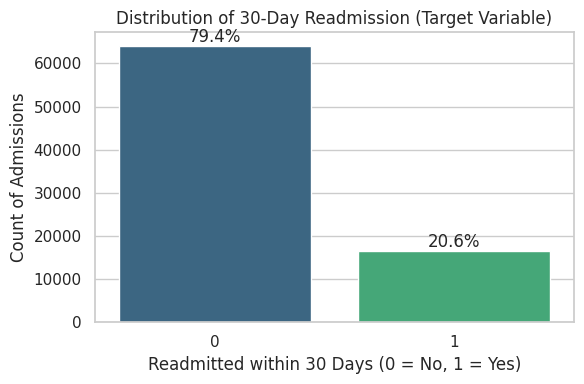

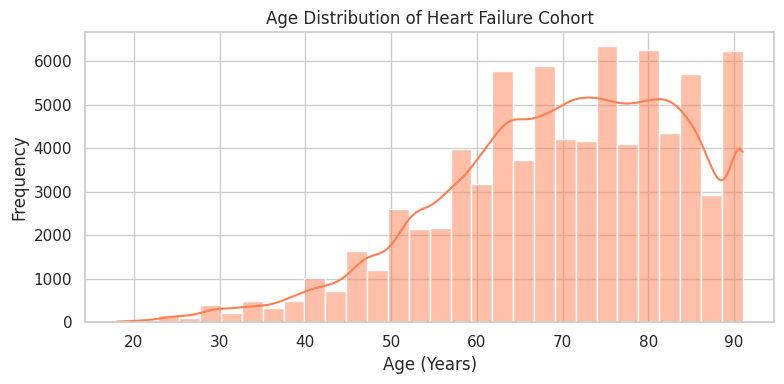

/tmp/ipykernel_287/2451582024.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_eda[df_eda['LOS'] < 50], x='READMIT_30_DAYS', y='LOS', palette='Set2')


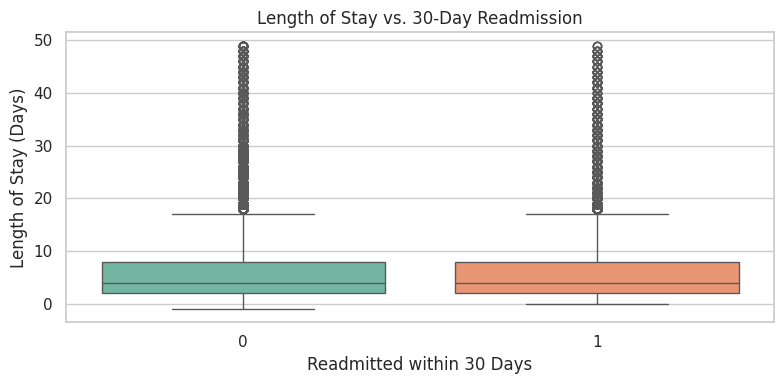

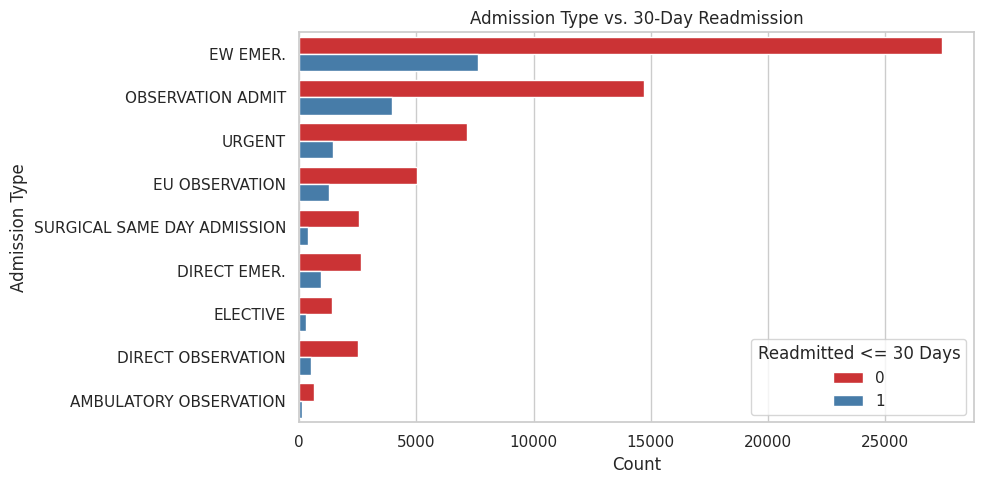

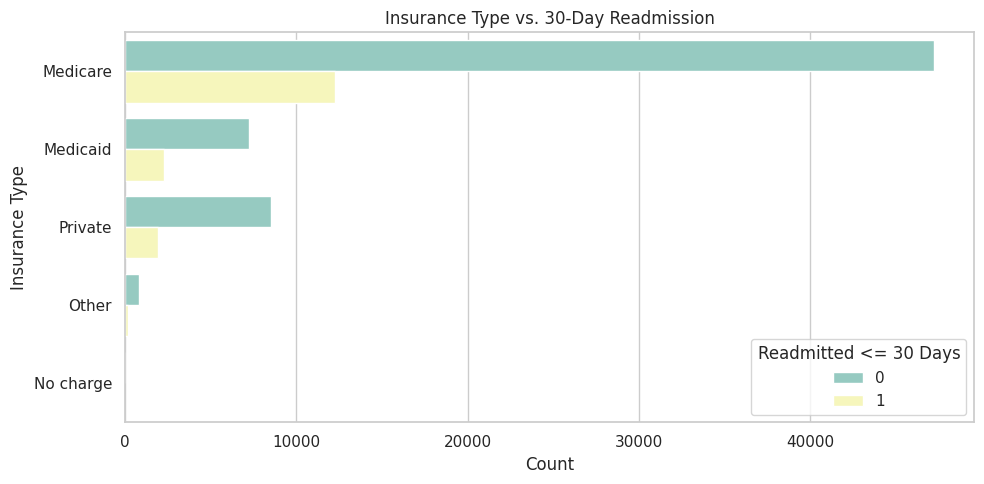

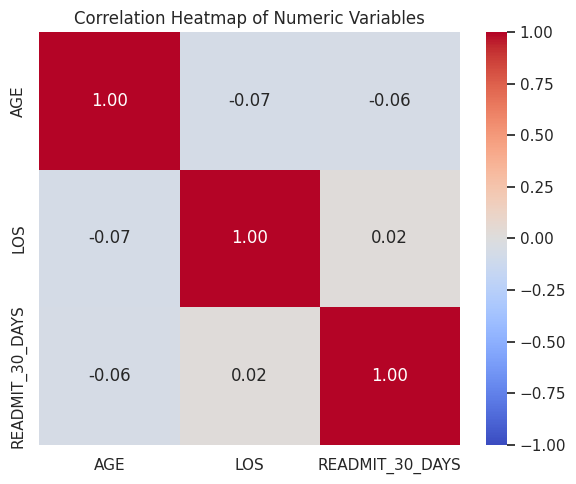

EDA plots generated successfully!


In [ ]:
# ==========================================
# 3.5. Exploratory Data Analysis (EDA) - Extended
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

print("Generating Exploratory Data Analysis (EDA) plots...")

# Plot 1: Class Imbalance
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df_hf_adm, x='READMIT_30_DAYS', palette='viridis')
plt.title('Distribution of 30-Day Readmission (Target Variable)')
plt.xlabel('Readmitted within 30 Days (0 = No, 1 = Yes)')
plt.ylabel('Count of Admissions')
total = len(df_hf_adm)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom')
plt.tight_layout()
plt.show()

# Merge for Age and LOS plots
df_eda = pd.merge(df_hf_adm, df_pat, on='SUBJECT_ID', how='left')

# Handle Age calculation based on MIMIC version
if 'DOB' in df_eda.columns:
    df_eda['DOB'] = pd.to_datetime(df_eda['DOB'])
    df_eda['AGE'] = (df_eda['ADMITTIME'] - df_eda['DOB']).dt.days / 365.25
else:
    df_eda['AGE'] = df_eda['ANCHOR_AGE'] # MIMIC-IV handles age directly

df_eda['AGE'] = np.where(df_eda['AGE'] > 120, 90, df_eda['AGE'])
df_eda['LOS'] = (df_eda['DISCHTIME'] - df_eda['ADMITTIME']).dt.days

# Plot 2: Age Distribution
plt.figure(figsize=(8, 4))
sns.histplot(df_eda['AGE'].dropna(), bins=30, kde=True, color='coral')
plt.title('Age Distribution of Heart Failure Cohort')
plt.xlabel('Age (Years)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# Plot 3: LOS vs Readmission
plt.figure(figsize=(8, 4))
sns.boxplot(data=df_eda[df_eda['LOS'] < 50], x='READMIT_30_DAYS', y='LOS', palette='Set2')
plt.title('Length of Stay vs. 30-Day Readmission')
plt.xlabel('Readmitted within 30 Days')
plt.ylabel('Length of Stay (Days)')
plt.tight_layout()
plt.show()

# Plot 4: Admission Type vs Readmission
plt.figure(figsize=(10, 5))
sns.countplot(data=df_eda, y='ADMISSION_TYPE', hue='READMIT_30_DAYS', palette='Set1')
plt.title('Admission Type vs. 30-Day Readmission')
plt.xlabel('Count')
plt.ylabel('Admission Type')
plt.legend(title='Readmitted <= 30 Days', loc='lower right')
plt.tight_layout()
plt.show()

# Plot 5: Insurance Type vs Readmission
plt.figure(figsize=(10, 5))
sns.countplot(data=df_eda, y='INSURANCE', hue='READMIT_30_DAYS', palette='Set3')
plt.title('Insurance Type vs. 30-Day Readmission')
plt.xlabel('Count')
plt.ylabel('Insurance Type')
plt.legend(title='Readmitted <= 30 Days', loc='lower right')
plt.tight_layout()
plt.show()

# Plot 6: Correlation Heatmap for Numeric Features
plt.figure(figsize=(6, 5))
numeric_df = df_eda[['AGE', 'LOS', 'READMIT_30_DAYS']].dropna()
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Numeric Variables')
plt.tight_layout()
plt.show()

print("EDA plots generated successfully!")

In [ ]:
# ==========================================
# 4. Feature Engineering & Logging
# ==========================================
print("--- Starting Feature Engineering ---")
print(f"Initial columns available before merging: {list(df_hf_adm.columns)}")

df_model = pd.merge(df_hf_adm, df_pat, on='SUBJECT_ID', how='left')
print(f"Columns after merging with patient data: {list(df_model.columns)}")

# Dynamic Age Calculation
if 'DOB' in df_model.columns:
    print("-> Detected MIMIC-III: Calculating AGE from DOB and ADMITTIME.")
    df_model['DOB'] = pd.to_datetime(df_model['DOB'])
    df_model['AGE'] = (df_model['ADMITTIME'] - df_model['DOB']).dt.days / 365.25
else:
    print("-> Detected MIMIC-IV: Using ANCHOR_AGE.")
    df_model['AGE'] = df_model['ANCHOR_AGE']

# Capping age and calculating LOS
df_model['AGE'] = np.where(df_model['AGE'] > 120, 90, df_model['AGE'])
df_model['LOS'] = (df_model['DISCHTIME'] - df_model['ADMITTIME']).dt.days
print("-> Engineered features: 'AGE', 'LOS' (Length of Stay in days).")

features = ['AGE', 'GENDER', 'ADMISSION_TYPE', 'INSURANCE', 'LOS']
target = 'READMIT_30_DAYS'

print(f"\nSelecting final features for the model: {features}")
print(f"Target variable: '{target}'")

df_final = df_model[features + [target]].copy()

initial_rows = len(df_final)
df_final = df_final[df_final['LOS'] > 0] # Remove negative LOS anomalies
dropped_rows = initial_rows - len(df_final)

print(f"\nData cleaning: Dropped {dropped_rows} rows with negative Length of Stay (data entry anomalies).")
print(f"Final dataset shape for modeling: {df_final.shape}")

print("\nSample of the final engineered dataset:")
display(df_final.head())

--- Starting Feature Engineering ---
Initial columns available before merging: ['SUBJECT_ID', 'HADM_ID', 'ADMITTIME', 'DISCHTIME', 'ADMISSION_TYPE', 'INSURANCE', 'NEXT_ADMITTIME', 'DAYS_TO_NEXT_ADMISSION', 'READMIT_30_DAYS']
Columns after merging with patient data: ['SUBJECT_ID', 'HADM_ID', 'ADMITTIME', 'DISCHTIME', 'ADMISSION_TYPE', 'INSURANCE', 'NEXT_ADMITTIME', 'DAYS_TO_NEXT_ADMISSION', 'READMIT_30_DAYS', 'GENDER', 'ANCHOR_AGE']
-> Detected MIMIC-IV: Using ANCHOR_AGE.
-> Engineered features: 'AGE', 'LOS' (Length of Stay in days).

Selecting final features for the model: ['AGE', 'GENDER', 'ADMISSION_TYPE', 'INSURANCE', 'LOS']
Target variable: 'READMIT_30_DAYS'

Data cleaning: Dropped 6964 rows with negative Length of Stay (data entry anomalies).
Final dataset shape for modeling: (73647, 6)

Sample of the final engineered dataset:


,AGE,GENDER,ADMISSION_TYPE,INSURANCE,LOS,READMIT_30_DAYS
0,86,F,EW EMER.,Medicare,4,0
1,86,F,EW EMER.,Medicare,7,0
2,86,F,EW EMER.,Medicare,9,0
3,86,F,EW EMER.,Medicare,1,0
4,73,F,EW EMER.,Medicare,1,0


In [ ]:
# ==========================================
# 5. Preprocessing & Train/Test Split
# ==========================================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

print("--- Starting Preprocessing & Splitting ---")
print(f"Total dataset size before split: {len(df_final)} rows.")

X = df_final.drop(columns=[target])
y = df_final[target]

# Split data: 80% for training, 20% for testing.
# stratify=y ensures the 20% readmission rate is maintained in both sets.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"-> Train set shape: {X_train.shape} | Train set Readmission Rate: {y_train.mean():.2%}")
print(f"-> Test set shape:  {X_test.shape} | Test set Readmission Rate:  {y_test.mean():.2%}")

# Define which columns are numeric and which are categorical
numeric_features = ['AGE', 'LOS']
categorical_features = ['GENDER', 'ADMISSION_TYPE', 'INSURANCE']

print(f"\nNumeric features to be scaled & imputed: {numeric_features}")
print(f"Categorical features to be one-hot encoded & imputed: {categorical_features}")

# Create transformers for numeric and categorical data
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), # Fill missing numbers with median
    ('scaler', StandardScaler())                   # Normalize numeric data
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')), # Fill missing categories with mode
    ('onehot', OneHotEncoder(handle_unknown='ignore'))    # Convert text categories to binary columns
])

# Combine into a single preprocessor step
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

print("\nData preprocessing pipeline defined successfully!")

--- Starting Preprocessing & Splitting ---
Total dataset size before split: 73647 rows.
-> Train set shape: (58917, 5) | Train set Readmission Rate: 20.87%
-> Test set shape:  (14730, 5) | Test set Readmission Rate:  20.87%

Numeric features to be scaled & imputed: ['AGE', 'LOS']
Categorical features to be one-hot encoded & imputed: ['GENDER', 'ADMISSION_TYPE', 'INSURANCE']

Data preprocessing pipeline defined successfully!


In [ ]:
# ==========================================
# 6. Model Training
# ==========================================

# A. Baseline Model: Logistic Regression
# Great for interpretability and establishing a baseline performance metric.
log_reg = Pipeline(steps=[('preprocessor', preprocessor),
                          ('classifier', LogisticRegression(class_weight='balanced', random_state=42))])

print("Training Logistic Regression Baseline...")
log_reg.fit(X_train, y_train)

# B. Advanced Model: Random Forest
# Captures non-linear relationships better than logistic regression.
rf_clf = Pipeline(steps=[('preprocessor', preprocessor),
                         ('classifier', RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42))])

print("Training Random Forest Classifier...")
rf_clf.fit(X_train, y_train)

print("Models trained successfully!")

Training Logistic Regression Baseline...
Training Random Forest Classifier...
Models trained successfully!


/tmp/ipykernel_287/590834170.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_imp_df, x='Importance', y='Feature', palette='mako')


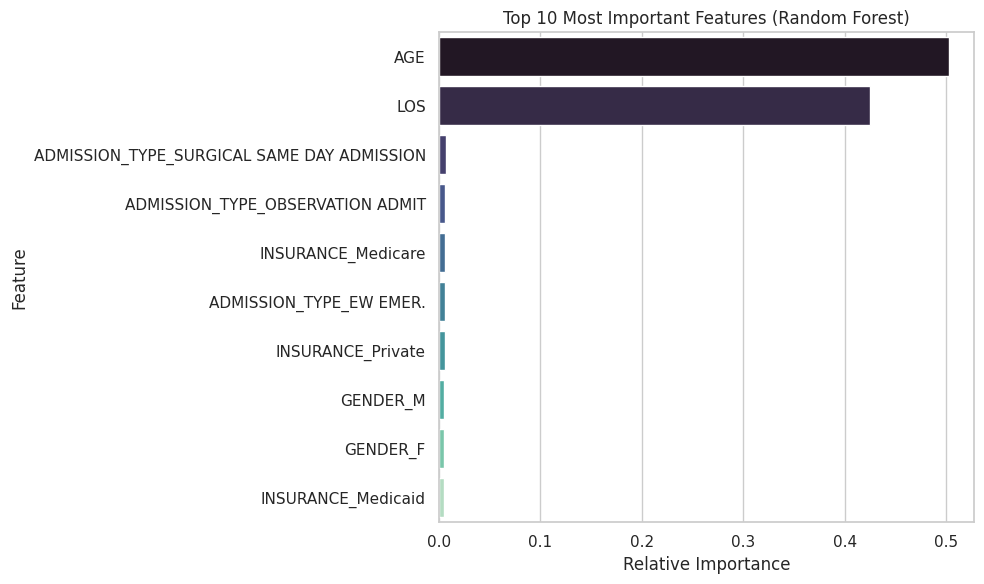

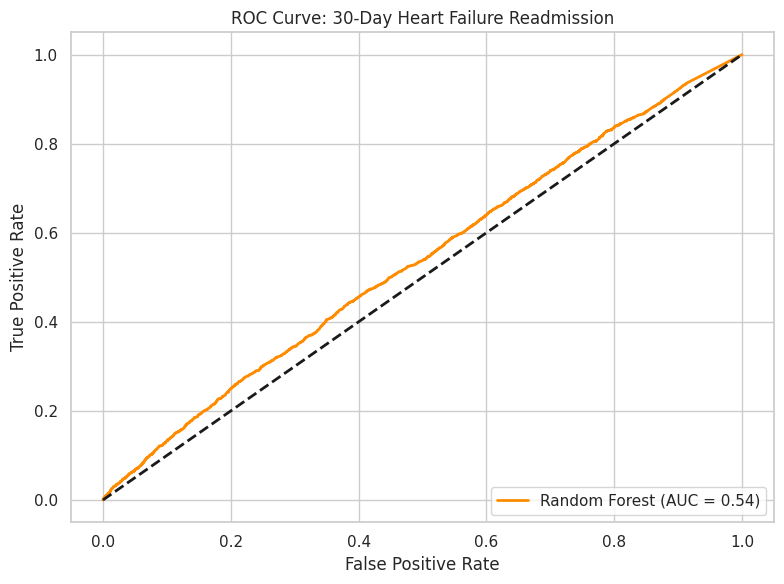

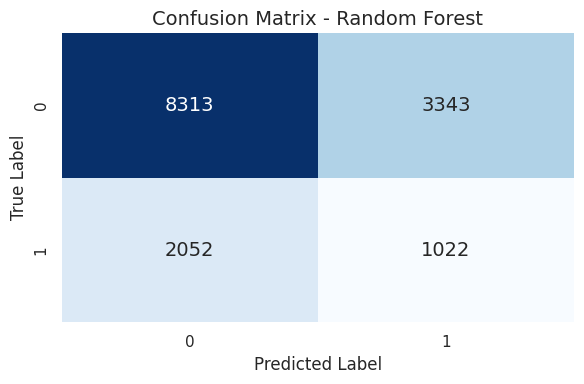

In [ ]:
# ==========================================
# 7. Model Evaluation & Feature Importance
# ==========================================

# Get predictions
y_pred_rf = rf_clf.predict(X_test)
y_prob_rf = rf_clf.predict_proba(X_test)[:, 1]

# Plot 4: Feature Importance (Crucial for ML interpretability slides)
# We need to extract the feature names from our preprocessor pipeline
numeric_cols = numeric_features
categorical_cols = rf_clf.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_features)
all_feature_names = np.concatenate([numeric_cols, categorical_cols])

# Extract feature importances from the Random Forest model
importances = rf_clf.named_steps['classifier'].feature_importances_

# Create a DataFrame and sort
feat_imp_df = pd.DataFrame({'Feature': all_feature_names, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=False).head(10) # Top 10 features

plt.figure(figsize=(10, 6))
sns.barplot(data=feat_imp_df, x='Importance', y='Feature', palette='mako')
plt.title('Top 10 Most Important Features (Random Forest)')
plt.xlabel('Relative Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# Plot 5: ROC Curve
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_score(y_test, y_prob_rf):.2f})', color='darkorange', lw=2)
plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve: 30-Day Heart Failure Readmission')
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# Plot 6: Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, annot_kws={"size": 14})
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Confusion Matrix - Random Forest', fontsize=14)
plt.tight_layout()
plt.show()